In [1]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_openrouter import ChatOpenRouter
# from langchain_openrouter import OpenRouterEmbeddings
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition
import os
import os
import requests
from langchain_core.embeddings import Embeddings
from tqdm import tqdm


c:\Users\Khushbu.Kushvaha\Desktop\Kk\Langgraph_learn\my_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Khushbu.Kushvaha\AppData\Local\Temp\ipykernel_14240\1965948765.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


In [2]:
load_dotenv()

True

In [3]:
# !pip install langchain-huggingface sentence-transformers

from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-small-en-v1.5",
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True},
)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4105.69it/s]


In [4]:
# llm = ChatOpenRouter(model='nvidia/nemotron-3-nano-30b-a3b:free')

llm = ChatOpenAI(
    model="nvidia/nemotron-3-nano-30b-a3b:free",   # or any OpenRouter model
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
)

# llm = ChatOpenAI(
#     base_url="https://openrouter.ai/api/v1",
#     api_key=os.environ["OPENROUTER_API_KEY"],
#     model="deepseek/deepseek-chat-v3"
# )

In [5]:
loader = PyPDFLoader('images_md/Timothy-Ferriss-The-4-Hour-Workweek-.pdf')

docs = loader.load()

In [6]:
len(docs)

279

In [7]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)

chunks = splitter.split_documents(docs)

In [8]:
len(chunks)

877

In [9]:
# class OpenRouterEmbeddings(Embeddings):
#     def __init__(self, model: str, api_key: str):
#         self.model = model
#         self.api_key = api_key
#         self.url = "https://openrouter.ai/api/v1/embeddings"

#     def _embed(self, inputs):
#         response = requests.post(
#             self.url,
#             headers={
#                 "Authorization": f"Bearer {self.api_key}",
#                 "Content-Type": "application/json",
#             },
#             json={
#                 "model": self.model,
#                 "input": inputs,
#             },
#         )

#         data = response.json()

#         if "data" not in data:
#             print("=" * 80)
#             print("INPUT:", inputs)
#             print("STATUS:", response.status_code)
#             print("RESPONSE:", data)
#             raise RuntimeError("Embedding API did not return 'data'")

#         return [x["embedding"] for x in data["data"]]

#     def embed_documents(self, texts):
#         batch_size = 64
#         all_embeddings = []

#         for i in tqdm(range(0, len(texts), batch_size)):
#             batch = texts[i:i + batch_size]
#             all_embeddings.extend(self._embed(batch))

#         print(f"Texts: {len(texts)}")
#         print(f"Embeddings: {len(all_embeddings)}")

#         return all_embeddings

#     def embed_query(self, text):
#         return self._embed([text])[0]

In [10]:
# embeddings = OpenRouterEmbeddings(
#     model="nvidia/llama-nemotron-embed-vl-1b-v2:free",
#     api_key=os.environ["OPENROUTER_API_KEY"],
# )

# # nvidia/llama-nemotron-embed-vl-1b-v2:free

In [11]:
# embeddings.embed_query("A")

In [12]:
# embeddings.embed_documents(["A", "B"])

In [13]:
# # Also check for empty chunks

# empty = [i for i, c in enumerate(chunks) if not c.page_content.strip()]
# print("Empty chunks:", empty[:20])
# print("Count:", len(empty))

In [14]:
# lengths = [len(c.page_content) for c in chunks]

# print("Min:", min(lengths))
# print("Max:", max(lengths))
# print("Total chunks:", len(lengths))

In [15]:
vector_store = FAISS.from_documents(chunks, embeddings)

In [16]:
# import requests
# import os

# response = requests.post(
#     "https://openrouter.ai/api/v1/embeddings",
#     headers={
#         "Authorization": f"Bearer {os.environ['OPENROUTER_API_KEY']}",
#         "Content-Type": "application/json",
#     },
#     json={
#         "model": "nvidia/nemotron-3-embed-1b:free",
#         "input": ["Hello", "World"],   # Note: list input
#     },
# )

# data = response.json()

# print(len(data["data"]))
# print(len(data["data"][0]["embedding"]))

In [17]:
vector_store

In [ ]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':3})

In [19]:
# retriever.invoke('What is the main idea of The 4-Hour Workweek?')

In [20]:
@tool
def rag_tool(query):
    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions that might be answered from the stored documents.
    """
    similar_chunks = retriever.invoke(query)

    context = [doc.page_content for doc in similar_chunks]
    metadata = [doc.metadata for doc in similar_chunks]

    return {
        'query': query,
        'context': context,
        'metadata': metadata
    }

In [21]:
tools = [rag_tool]

llm_with_tool = llm.bind_tools(tools)

In [22]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [23]:
# def chat_node(state: ChatState):
#     messages = state['messages']

#     response = llm_with_tool.invoke(messages)

#     return {'messages': [response]}

def chat_node(state: ChatState):
    print("=" * 50)
    print(state)
    print("=" * 50)

    messages = state["messages"]

    print(messages)

    response = llm_with_tool.invoke(messages)

    return {"messages": [response]}

In [24]:
tool_node = ToolNode(tools)

In [25]:
graph = StateGraph(ChatState)

# add nodes 
graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

# add edge
graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph. add_edge('tools', 'chat_node')

chatbot = graph.compile()

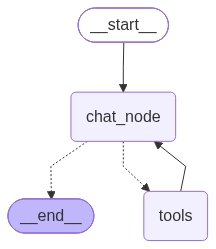

In [26]:
chatbot

In [27]:
answer = chatbot.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    'What is the main idea of The 4-Hour Workweek?'
                )
            )
        ]
    }
)

{'messages': [HumanMessage(content='What is the main idea of The 4-Hour Workweek?', additional_kwargs={}, response_metadata={}, id='002ef837-a5d0-43b5-a6f7-291d6290ebdf')]}
[HumanMessage(content='What is the main idea of The 4-Hour Workweek?', additional_kwargs={}, response_metadata={}, id='002ef837-a5d0-43b5-a6f7-291d6290ebdf')]
{'messages': [HumanMessage(content='What is the main idea of The 4-Hour Workweek?', additional_kwargs={}, response_metadata={}, id='002ef837-a5d0-43b5-a6f7-291d6290ebdf'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 128, 'prompt_tokens': 297, 'total_tokens': 425, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 95, 'rejected_prediction_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': 0, 'cached_tokens': 0, 'video_tokens': 0}, 'cost': 0, 'is_byok': False, 'cost_details': {'upstream_in

In [28]:
print(answer['messages'][-1].content)

The central premise of *The 4‑Hour Workweek* is that you can redesign how you work so that you spend far fewer hours on the job while still earning and living on your own terms.  It advocates using automation, outsourcing, and “mini‑retirement” breaks to create a mobile, flexible lifestyle—often summarized as achieving a “four‑hour workweek” that prioritizes freedom, quality of life, and personal fulfillment over the traditional 9‑to‑5 grind.
